In [2]:
import pandas as pd


dosya_yolu = r"C:\Users\fatoş\Desktop\BigData-Pipeline-Project\data\olist_orders_dataset.csv"

print("Yol başarıyla tanımlandı!")

Yol başarıyla tanımlandı!


In [3]:
import os

# Dosyaların durduğu ana klasörü bu yoldan otomatik buluyoruz
klasor = os.path.dirname(dosya_yolu)

# Şimdi ilk iki ana dosyamızı okutuyoruz
orders = pd.read_csv(os.path.join(klasor, "olist_orders_dataset.csv"))
order_items = pd.read_csv(os.path.join(klasor, "olist_order_items_dataset.csv"))

print("İlk iki dosya başarıyla okundu!")
print("Sipariş satır sayısı:", len(orders))
print("Sipariş detay satır sayısı:", len(order_items))

İlk iki dosya başarıyla okundu!
Sipariş satır sayısı: 99441
Sipariş detay satır sayısı: 112650


In [4]:
# 1. Tablolarda tamamen aynı olan hatalı çift kayıtlar var mı bakıyoruz
print("Siparişler tablosundaki mükerrer satır sayısı:", orders.duplicated().sum())
print("Sipariş detayları tablosundaki mükerrer satır sayısı:", order_items.duplicated().sum())

# 2. Eğer varsa bu mükerrer kayıtları temizliyoruz
orders = orders.drop_duplicates()
order_items = order_items.drop_duplicates()

print("Mükerrer veri kontrolü ve temizliği tamamlandı!")

Siparişler tablosundaki mükerrer satır sayısı: 0
Sipariş detayları tablosundaki mükerrer satır sayısı: 0
Mükerrer veri kontrolü ve temizliği tamamlandı!


In [5]:
# 1. Ürünler ve çeviri dosyalarını bilgisayardaki o klasörden okutuyoruz
products = pd.read_csv(os.path.join(klasor, "olist_products_dataset.csv"))
translation = pd.read_csv(os.path.join(klasor, "product_category_name_translation.csv"))

# 2. Portekizce isimler ile İngilizce karşılıklarını birleştiriyoruz (Sözlükten bakıp eşleştiriyoruz)
products = pd.merge(products, translation, on="product_category_name", how="left")

# 3. Kafamız karışmasın diye eski Portekizce sütunu silip, yeni İngilizce sütunun adını düzeltiyoruz
products = products.drop(columns=["product_category_name"])
products = products.rename(columns={"product_category_name_english": "product_category_name"})

print("Kategoriler başarıyla İngilizceye çevrildi!")
print("Yeni tablodaki ilk 3 ürünün İngilizce kategorisi:")
print(products["product_category_name"].head(3))

Kategoriler başarıyla İngilizceye çevrildi!
Yeni tablodaki ilk 3 ürünün İngilizce kategorisi:
0         perfumery
1               art
2    sports_leisure
Name: product_category_name, dtype: object


In [6]:
# Sipariş detayları (order_items) ile İngilizceye çevirdiğimiz ürünleri (products) birleştiriyoruz
# Böylece her sipariş satırının yanına o ürünün İngilizce kategorisi otomatik eklenecek.
siparis_detay_raporu = pd.merge(order_items, products[["product_id", "product_category_name"]], on="product_id", how="left")

print("Tablolar başarıyla birleştirildi!")
print("Rapor tablomuzdaki sütunlar:\n", siparis_detay_raporu.columns.tolist())

Tablolar başarıyla birleştirildi!
Rapor tablomuzdaki sütunlar:
 ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name']


In [7]:
# 1. Toplam ciro ve satılan toplam ürün adedini hesaplıyoruz
toplam_ciro = siparis_detay_raporu["price"].sum()
toplam_urun_adedi = len(siparis_detay_raporu)

print("--- GENEL SATIŞ RAPORU ---")
print(f"Şirketin Toplam Cirosu: {toplam_ciro:,.2f} USD")
print(f"Satılan Toplam Ürün Adedi: {toplam_urun_adedi:,} adet")

--- GENEL SATIŞ RAPORU ---
Şirketin Toplam Cirosu: 13,591,643.70 USD
Satılan Toplam Ürün Adedi: 112,650 adet


In [8]:
# Kategorilere göre ciroyu (price) topluyoruz, büyükten küçüğe sıralayıp ilk 5 tanesini seçiyoruz
en_cok_kazandiranlar = siparis_detay_raporu.groupby("product_category_name")["price"].sum().sort_values(ascending=False).head(5)

print("--- ŞİRKETE EN ÇOK PARA KAZANDIRAN İLK 5 KATEGORİ ---")
print(en_cok_kazandiranlar)

--- ŞİRKETE EN ÇOK PARA KAZANDIRAN İLK 5 KATEGORİ ---
product_category_name
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
Name: price, dtype: float64


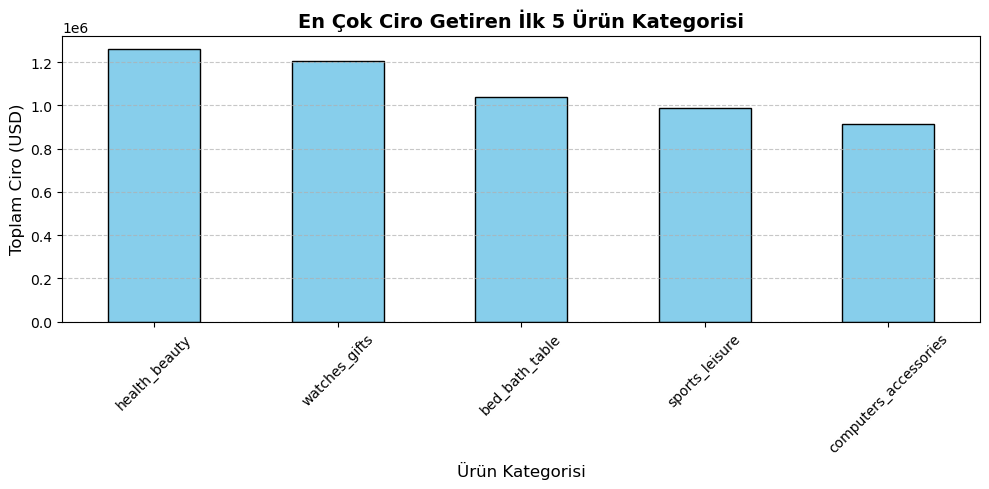

In [9]:
import matplotlib.pyplot as plt

# Grafik boyutunu ayarlıyoruz ve şık bir çubuk grafiği çizdiriyoruz
plt.figure(figsize=(10, 5))
en_cok_kazandiranlar.plot(kind="bar", color="skyblue", edgecolor="black")

# Grafiğin başlıklarını ve yazılarını süslüyoruz
plt.title("En Çok Ciro Getiren İlk 5 Ürün Kategorisi", fontsize=14, fontweight="bold")
plt.xlabel("Ürün Kategorisi", fontsize=12)
plt.ylabel("Toplam Ciro (USD)", fontsize=12)
plt.xticks(rotation=45) # Yazılar birbirine girmesin diye yan yatırıyoruz
plt.grid(axis="y", linestyle="--", alpha=0.7) # Arkaya hafif çizgiler ekliyoruz

# Grafiği ekranda gösteriyoruz
plt.tight_layout()
plt.show()

In [10]:
# 1. Sipariş tarihi sütununu Python'ın anlayacağı gerçek bir tarih formatına çeviriyoruz
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

# 2. Tarihlerin içinden sadece "Yıl-Ay" bilgisini çekip yeni bir sütun yapıyoruz
orders["year_month"] = orders["order_purchase_timestamp"].dt.to_period("M")

# 3. Aylara göre toplam kaç tane sipariş (order_id) verilmiş sayıyoruz ve kronolojik sıralıyoruz
aylik_siparisler = orders.groupby("year_month")["order_id"].count().sort_index()

print("--- AYLARA GÖRE SİPARİŞ SAYILARI ---")
print(aylik_siparisler.tail(5)) # Son 5 ayın özetini ekranda görmek için

--- AYLARA GÖRE SİPARİŞ SAYILARI ---
year_month
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64


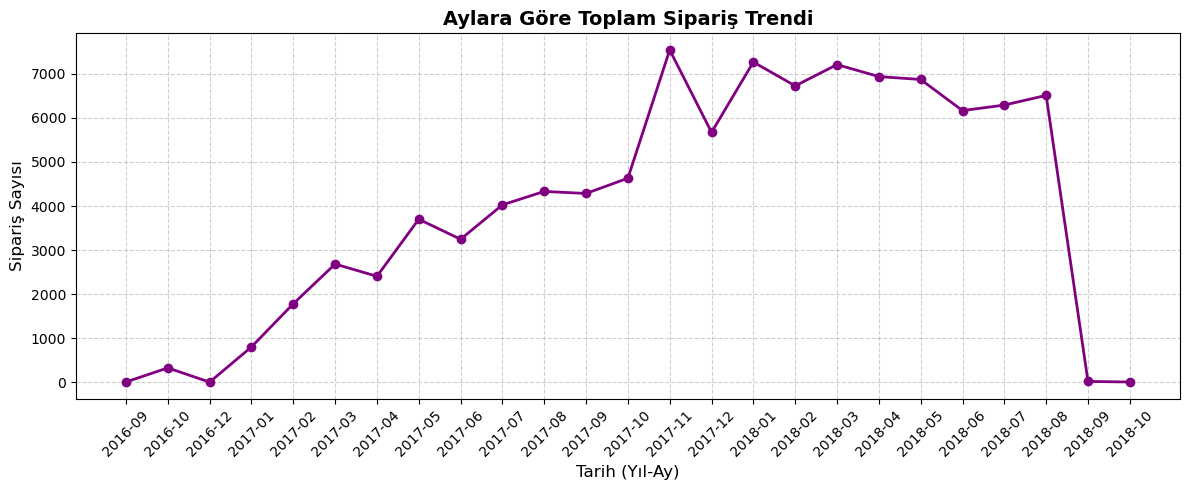

In [11]:
# Zaman serisi çizimi için indeksimizi yazı formatına çeviriyoruz
aylik_siparisler.index = aylik_siparisler.index.astype(str)

plt.figure(figsize=(12, 5))
# Çizgi grafiği çizdiriyoruz (marker="o" çizgi üzerindeki noktaları belirginleştirir)
plt.plot(aylik_siparisler.index, aylik_siparisler.values, marker="o", color="purple", linewidth=2)

# Grafiğin başlıklarını ve düzenlemelerini yapıyoruz
plt.title("Aylara Göre Toplam Sipariş Trendi", fontsize=14, fontweight="bold")
plt.xlabel("Tarih (Yıl-Ay)", fontsize=12)
plt.ylabel("Sipariş Sayısı", fontsize=12)
plt.xticks(rotation=45) # Tarihler birbirine girmesin diye yan yatırıyoruz
plt.grid(True, linestyle="--", alpha=0.6) # Arkaya kareli kılavuz çizgileri ekliyoruz

# Grafiği gösteriyoruz
plt.tight_layout()
plt.show()

In [12]:
# 1. Müşteri veri setini okuyoruz
customers = pd.read_csv(os.path.join(klasor, "olist_customers_dataset.csv"))

# 2. Siparişler (orders) ile Müşterileri (customers) "customer_id" üzerinden birleştiriyoruz
orders_with_cities = pd.merge(orders, customers[["customer_id", "customer_city"]], on="customer_id", how="left")

# 3. Şehirlere göre sipariş sayılarını sayıp, en yüksek olan ilk 5 şehri buluyoruz
en_aktif_sehirler = orders_with_cities["customer_city"].value_counts().head(5)

print("--- EN ÇOK SİPARİŞ VEREN İLK 5 ŞEHİR ---")
print(en_aktif_sehirler)

--- EN ÇOK SİPARİŞ VEREN İLK 5 ŞEHİR ---
customer_city
sao paulo         15540
rio de janeiro     6882
belo horizonte     2773
brasilia           2131
curitiba           1521
Name: count, dtype: int64


In [14]:
# 1. Merkezdeki Fact (Sipariş detayları) tablosunu alıyoruz
# 2. Etrafındaki Dimension (Ürünler ve Müşteriler) tablolarını tek seferde bağlıyoruz

# Önce ürün kategorilerini İngilizceye çevirdiğimiz products tablosuyla birleştiriyoruz
yildiz_tablosu = pd.merge(order_items, products[["product_id", "product_category_name"]], on="product_id", how="left")

# Şimdi sipariş tarihi (year_month) için orders tablosunu bağlıyoruz
yildiz_tablosu = pd.merge(yildiz_tablosu, orders[["order_id", "year_month", "customer_id"]], on="order_id", how="left")

# Son olarak müşteri şehir ve eyaletleri için customers tablosunu bağlıyoruz
yildiz_tablosu = pd.merge(yildiz_tablosu, customers[["customer_id", "customer_city", "customer_state"]], on="customer_id", how="left")

# Tablonun oluşup oluşmadığını kontrol etmek için ilk 3 satırını ekrana yazdırıyoruz
yildiz_tablosu.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,year_month,customer_id,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,cool_stuff,2017-09,3ce436f183e68e07877b285a838db11a,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,pet_shop,2017-04,f6dd3ec061db4e3987629fe6b26e5cce,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,furniture_decor,2018-01,6489ae5e4333f3693df5ad4372dab6d3,para de minas,MG


In [15]:
# Kurduğumuz yıldız_tablosu üzerinden satıcı bazlı ciro analizi yapıyoruz
en_basarili_saticilar = yildiz_tablosu.groupby("seller_id")["price"].sum().sort_values(ascending=False).head(5)

print("--- EN ÇOK CİRO YAPAN İLK 5 SATICI ---")
print(en_basarili_saticilar)

--- EN ÇOK CİRO YAPAN İLK 5 SATICI ---
seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
Name: price, dtype: float64


In [22]:
import pandas as pd

# Merkezdeki Fact (Sipariş detayları) tablosuna, etraftaki tüm Boyut (Dimension) tabloları bağlanır
# 1. Ürün Boyutu Bağlantısı (Kategoriler)
yildiz_tablosu = pd.merge(order_items, products[["product_id", "product_category_name"]], on="product_id", how="left")

# 2. Sipariş Boyutu Bağlantısı (Zaman Serisi)
yildiz_tablosu = pd.merge(yildiz_tablosu, orders[["order_id", "year_month", "customer_id"]], on="order_id", how="left")

# 3. Müşteri Boyutu Bağlantısı (Coğrafi Konum)
yildiz_tablosu = pd.merge(yildiz_tablosu, customers[["customer_id", "customer_city", "customer_state"]], on="customer_id", how="left")